# Stage 3 — nonlinear embeddings (CEBRA / UMAP / Isomap)

Visualize the embeddings written by `src/03_nonlinear_embedding.py`. CA1 and PFC
are kept separate. CEBRA is behavior-aligned (trained on position+speed, NOT on
the novel/familiar label), so colouring by condition reveals the geometric
transformation rather than building it in.

1. 3-D embeddings per method, coloured by condition and by position
2. CEBRA training-loss curve
3. **Position decoding** (kNN, cross-validated) — a fair quantitative comparison
   of how much behavior each method's geometry captures, per method and region


## Setup

In [1]:
import sys, pathlib
for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / "src" / "config.py").exists():
        sys.path.insert(0, str(_p / "src")); break
import numpy as np
import matplotlib.pyplot as plt
from config import DATA_PROCESSED, BIN_SIZE_S
BIN_MS = int(BIN_SIZE_S * 1000)
plt.rcParams["figure.dpi"] = 100
COND_COLOR = {"novel": "tab:red", "familiar": "tab:blue"}
METHODS = ["cebra", "umap", "isomap"]
print("bin size:", BIN_MS, "ms")

bin size: 1000 ms


## Pick a subject/region and load its embeddings

In [2]:
subjects = sorted({f.stem.split("_")[2] for f in DATA_PROCESSED.glob(f"emb_*_{BIN_MS}ms.npz")})
print("subjects:", subjects)
SUBJECT = subjects[0]   # change me
REGION = "CA1"          # or "PFC"

emb = {}
for m in METHODS:
    f = DATA_PROCESSED / f"emb_{m}_{SUBJECT}_{REGION}_{BIN_MS}ms.npz"
    if f.exists():
        emb[m] = np.load(f, allow_pickle=False)
print(f"{SUBJECT} {REGION}: loaded methods", list(emb))

subjects: ['JDS-NFN-AM2', 'JDS-NFN-JS17', 'JDS-NFN-JS21', 'JDS-NFN-JS34', 'JDS-NFN-ZT2']
JDS-NFN-AM2 CA1: loaded methods ['cebra', 'umap', 'isomap']


## 1. Embeddings coloured by condition and position

Top row: novel (red) vs familiar (blue). Bottom row: coloured by x-position
(the track), to check the embedding is behaviorally organized.

C:\Users\proskurinm\AppData\Local\Temp\ipykernel_19828\4252759630.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


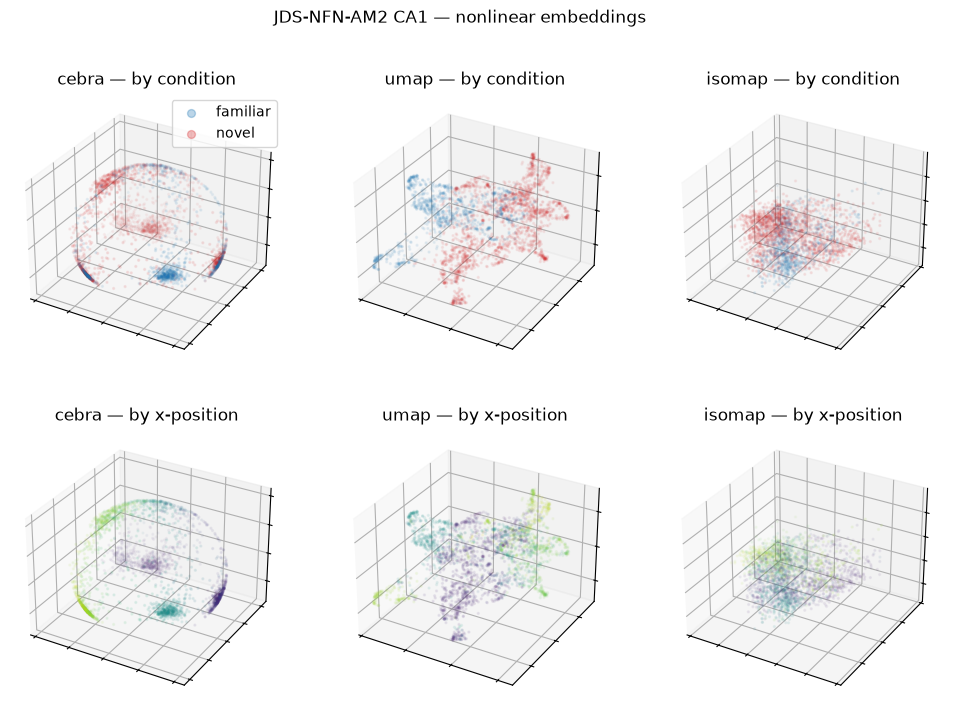

In [3]:
avail = list(emb)
fig = plt.figure(figsize=(4 * len(avail), 8))
for j, m in enumerate(avail):
    e = emb[m]["embedding"]; cond = emb[m]["condition"]; pos = emb[m]["position"]
    ax = fig.add_subplot(2, len(avail), j + 1, projection="3d")
    for c in np.unique(cond):
        mk = cond == c
        ax.scatter(e[mk, 0], e[mk, 1], e[mk, 2], s=2, alpha=0.3,
                   color=COND_COLOR.get(c), label=c)
    ax.set_title(f"{m} — by condition"); ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    if j == 0: ax.legend(markerscale=4)
    ax2 = fig.add_subplot(2, len(avail), len(avail) + j + 1, projection="3d")
    p = ax2.scatter(e[:, 0], e[:, 1], e[:, 2], s=2, alpha=0.3, c=pos[:, 0], cmap="viridis")
    ax2.set_title(f"{m} — by x-position"); ax2.set_xticklabels([]); ax2.set_yticklabels([]); ax2.set_zticklabels([])
fig.suptitle(f"{SUBJECT} {REGION} — nonlinear embeddings")
plt.tight_layout()

## 2. CEBRA training loss

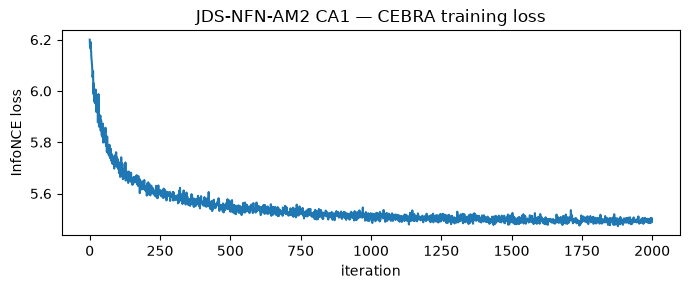

In [4]:
if "cebra" in emb and "cebra_loss" in emb["cebra"].files:
    loss = emb["cebra"]["cebra_loss"]
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(loss); ax.set_xlabel("iteration"); ax.set_ylabel("InfoNCE loss")
    ax.set_title(f"{SUBJECT} {REGION} — CEBRA training loss")
    plt.tight_layout()
else:
    print("no CEBRA loss recorded")

## 3. Position decoding (cross-validated kNN)

For every embedding we predict the animal's (x, y) from the embedding with a kNN
regressor (5-fold CV) and report R². Higher = the geometry encodes behavior
better. This is the apples-to-apples comparison across methods and regions.

region,CA1,PFC
method,,
cebra,0.948884,0.909515
isomap,0.352038,0.168333
umap,0.558994,0.281973


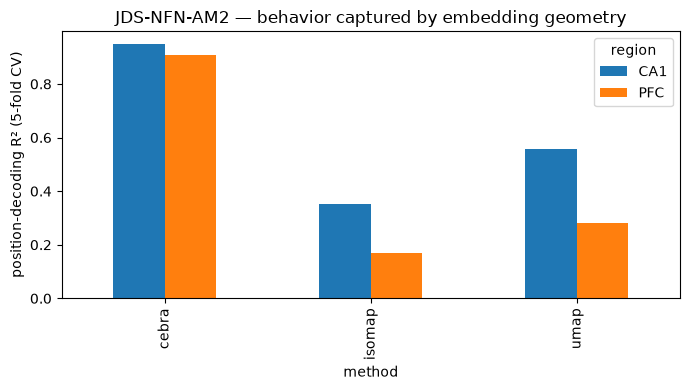

In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

def decode_r2(e, pos):
    ok = np.isfinite(pos).all(axis=1)
    knn = KNeighborsRegressor(n_neighbors=15)
    return cross_val_score(knn, e[ok], pos[ok], cv=5,
                           scoring="r2").mean()

rows = []
for region in ["CA1", "PFC"]:
    for m in METHODS:
        f = DATA_PROCESSED / f"emb_{m}_{SUBJECT}_{region}_{BIN_MS}ms.npz"
        if not f.exists():
            continue
        dd = np.load(f, allow_pickle=False)
        rows.append((region, m, decode_r2(dd["embedding"], dd["position"])))

import pandas as pd
tab = pd.DataFrame(rows, columns=["region", "method", "r2"])
piv = tab.pivot(index="method", columns="region", values="r2")
ax = piv.plot.bar(figsize=(7, 4)); ax.set_ylabel("position-decoding R² (5-fold CV)")
ax.set_title(f"{SUBJECT} — behavior captured by embedding geometry")
plt.tight_layout()
piv

---
**Next:** stage 4 (`src/04_cross_condition.py`) — Procrustes / CCA to align
novel vs. familiar and CA1 vs. PFC embeddings and quantify the transformation.